# Chapter 10 — Tail Risk and Dependence: EVT and Copulas

Read the chapter [`README.md`](./README.md) first. This notebook is the runnable companion.

Two oldest open promises in the curriculum land here:

- **Ch2 §1 fat tails** — measured but never modelled.
- **Ch3 §3 tail dependence** — the third correlation flavor, deferred because Pearson's conditional correlation suffers a known truncation artifact.

Chapter 10 closes both promises with **Extreme Value Theory** for univariate tails and the **tail dependence coefficient** for joint extremes. The §3.4 sidebar combines Ch9 GARCH with EVT — *filtered historical simulation*, the production-grade tail-VaR combination.

## What we mean by "tail-specific modeling"

Three questions; three tools:

| Question | Tool | Section |
|---|---|---|
| **How bad can one day get?** | EVT — Generalized Pareto Distribution via peaks-over-threshold | §2-4 |
| **Do bad days line up across assets?** | Tail dependence coefficient (empirical) | §5 |
| **Joint tail modelling, formally** | Copula + GPD marginals (named only) | §6 |

## 1. Setup

**SPY 20y daily log returns** for univariate EVT (same as Ch1-2). **SPY/TLT, SPY/XLF, SPY/XLK** for tail dependence (same as Ch3). No new packages — `scipy.stats.genpareto` already comes with scipy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import genpareto, norm
from scipy.optimize import minimize

print('imports ok')

imports ok


In [2]:
def to_series(x):
    if isinstance(x, pd.DataFrame): return x.squeeze() if x.shape[1] == 1 else x.iloc[:, 0]
    return x

spy = to_series(yf.download("SPY", period="20y", auto_adjust=True, progress=False)["Close"]).dropna()
spy_lr = np.log(spy / spy.shift(1)).dropna()
spy_lr.index = spy_lr.index.tz_localize(None) if spy_lr.index.tz else spy_lr.index
losses = -spy_lr  # positive = loss
N = len(losses)
print(f"SPY N = {N:,}; date range: {spy_lr.index.min().date()} to {spy_lr.index.max().date()}")

panel = yf.download(["SPY","TLT","XLF","XLK"], period="20y", auto_adjust=True, progress=False)["Close"].dropna()
panel.index = panel.index.tz_localize(None) if panel.index.tz else panel.index
panel_lr = np.log(panel / panel.shift(1)).dropna()
print(f"Panel shape: {panel_lr.shape}")

SPY N = 5,030; date range: 2006-05-08 to 2026-05-05


Panel shape: (5030, 4)


One-paragraph callback to Ch2 (fat tails) and Ch3 (tail dependence motivation). Ch2's Q-Q plot of SPY returns vs Normal — the "should never happen in human history" picture — is the *empirical motivation* for §2-4. Ch3 §3.4's conditional-correlation truncation table is the motivation for §5.

## 2. EVT preliminaries — block maxima vs peaks-over-threshold

EVT models the *tail* of a distribution. Two main flavors:

> **Block maxima (BM):** divide the data into non-overlapping blocks (e.g., calendar years), take the worst day in each block, fit a *Generalized Extreme Value (GEV)* distribution to the resulting block maxima.
>
> **Peaks over threshold (POT):** pick a high threshold *u*, take all observations above *u*, fit the *exceedances* (X − u | X > u) to a *Generalized Pareto Distribution (GPD)*.

**The choice for daily returns: POT.** With 20 years (~5,030 daily observations):

- BM with annual blocks gives only 20 maxima — wasteful with most of the data.
- POT at the 95th percentile gives ~250 exceedances — uses the actual tail.

POT is the daily-return choice. The rest of this chapter uses POT.

### 2.1 Pickands-Balkema-de Haan in plain English

The theorem behind POT-GPD: as the threshold *u* rises, the conditional distribution of (X − u | X > u) converges to a **Generalized Pareto Distribution** with shape ξ and scale σ. *No proof here.* This is *why* GPD is the right tail model — it's not arbitrary.

<details><summary>Pickands-Balkema-de Haan: why this works</summary>

For any distribution in the *max-domain-of-attraction* of a Generalized Extreme Value (GEV) distribution, exceedances above a sufficiently high threshold converge in distribution to GPD. Most distributions practitioners care about (Normal, Student-t, exponential, log-normal, Pareto) sit in this domain. The convergence is in distribution and is unique up to the parameters (ξ, σ).

</details>

### 2.2 The GPD

We need a distribution that flexibly handles three tail regimes (heavy / exponential / bounded) with two parameters. The GPD is that distribution. Read the formula below as *probability falls off as a power of the exceedance, with the power controlled by ξ.*

> f(y; ξ, σ) = (1/σ) · (1 + ξ·y/σ)<sup>−(1/ξ) − 1</sup>  for y ≥ 0 and 1 + ξ·y/σ > 0

where:
- *y* = X − u — the exceedance above threshold *u*. **Units:** decimal log-loss (positive).
- *σ* — scale parameter. Same units as y. *Always positive.*
- *ξ* — shape parameter. Dimensionless.

**Three regimes for ξ:**

| Regime | ξ | Tail | Examples |
|---|---|---|---|
| Heavy | ξ > 0 | Pareto-like; some moments don't exist | Daily equity returns; insurance losses |
| Exponential | ξ = 0 | Memoryless | Queueing-theory waiting times |
| Bounded | ξ < 0 | Has a hard upper limit | Annual rainfall (physical max) |

> **Pareto** — the prototypical heavy-tailed distribution; "Pareto-like" means tails decay polynomially (as a power), not exponentially.
> **Memoryless** — once you exceed the threshold, how much further you go is independent of how far you already went; the exponential is the only continuous memoryless distribution.

Daily-equity tails sit firmly in ξ > 0 (mildly heavy). The §3 fit lands ξ̂ ≈ 0.19 for SPY.

## 3. GPD fit on SPY losses

We sweep *u* from p50 to p99 and watch where the curve straightens; that flat region is where GPD fits well.

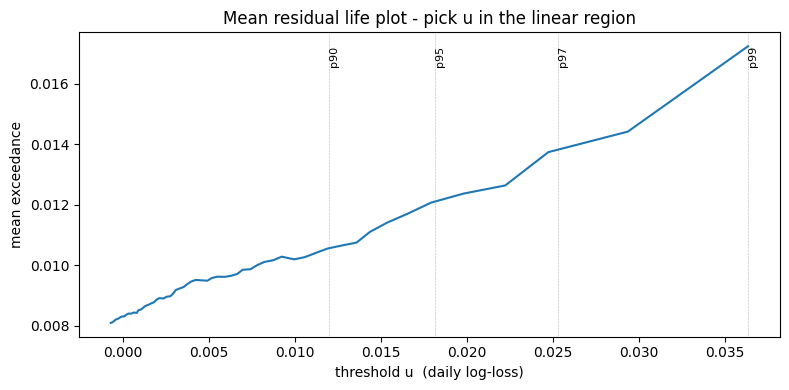

In [3]:
def mrl_at(losses_arr, u_):
    ex = losses_arr[losses_arr > u_] - u_
    return ex.mean() if len(ex) else np.nan

losses_arr = losses.values
us = np.quantile(losses_arr, np.linspace(0.50, 0.99, 60))
mrls = [mrl_at(losses_arr, u_) for u_ in us]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(us, mrls)
for q in [0.90, 0.95, 0.975, 0.99]:
    qv = np.quantile(losses_arr, q)
    ax.axvline(qv, color="gray", lw=0.4, ls=":")
    ax.text(qv, max(mrls), f"p{int(q*100)}", rotation=90, fontsize=8, va="top")
ax.set_xlabel("threshold u  (daily log-loss)"); ax.set_ylabel("mean exceedance")
ax.set_title("Mean residual life plot - pick u in the linear region")
fig.tight_layout(); plt.show()

**Reading the MRL plot.** Above the right threshold, the mean exceedance grows approximately linearly with *u* — that's the GPD theory talking. Below the right threshold, the curve bends (the data isn't yet in the tail). Pick *u* in the linear region. For SPY, the 95th percentile of losses (≈ 1.82%) is a standard practical choice and falls inside the linear region.

In [4]:
u = np.quantile(losses_arr, 0.95)
exceedances = losses_arr[losses_arr > u] - u
n_u = len(exceedances)
xi_hat, _, sigma_hat = genpareto.fit(exceedances, floc=0)
print(f"threshold u (p95): {u:.5f}")
print(f"exceedances:        {n_u}")
print(f"GPD fit: xi = {xi_hat:+.4f}, sigma = {sigma_hat:.5f}")
print(f"interpretation: xi {'>' if xi_hat > 0 else '≤'} 0 -> {'HEAVY tail' if xi_hat > 0 else 'exponential or bounded tail'}")

threshold u (p95): 0.01817
exceedances:        252
GPD fit: xi = +0.1910, sigma = 0.00991
interpretation: xi > 0 -> HEAVY tail


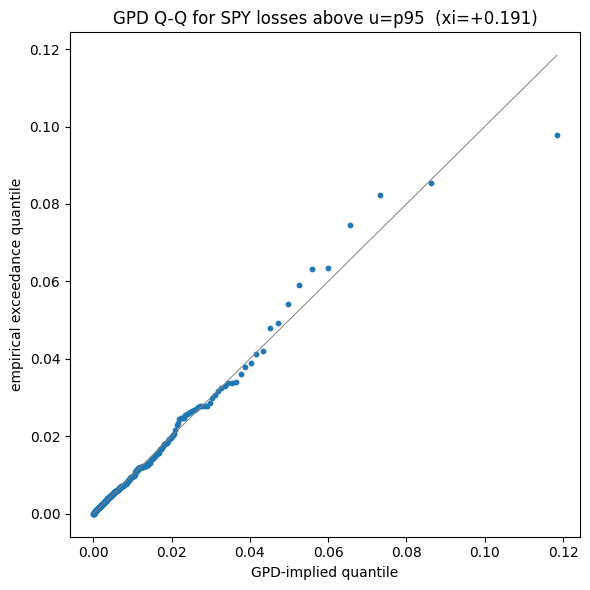

In [5]:
ex_sorted = np.sort(exceedances)
emp_q = (np.arange(1, n_u + 1) - 0.5) / n_u
gpd_q = genpareto.ppf(emp_q, xi_hat, loc=0, scale=sigma_hat)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(gpd_q, ex_sorted, s=10)
lim = max(gpd_q.max(), ex_sorted.max())
ax.plot([0, lim], [0, lim], color="gray", lw=0.7)
ax.set_xlabel("GPD-implied quantile"); ax.set_ylabel("empirical exceedance quantile")
ax.set_title(f"GPD Q-Q for SPY losses above u=p95  (xi={xi_hat:+.3f})")
fig.tight_layout(); plt.show()

In [6]:
rows = []
for p in [0.80, 0.90, 0.95, 0.975, 0.99]:
    up = np.quantile(losses_arr, p)
    ex = losses_arr[losses_arr > up] - up
    if len(ex) < 30:
        rows.append((p, up, len(ex), np.nan, np.nan)); continue
    xi_p, _, sig_p = genpareto.fit(ex, floc=0)
    rows.append((p, up, len(ex), xi_p, sig_p))
df_sens = pd.DataFrame(rows, columns=["pctile", "u", "n_u", "xi", "sigma"])
print(df_sens.round({"u": 5, "xi": 4, "sigma": 5}))

   pctile        u   n_u      xi    sigma
0   0.800  0.00598  1006  0.1639  0.00803
1   0.900  0.01201   503  0.1933  0.00855
2   0.950  0.01817   252  0.1910  0.00991
3   0.975  0.02531   126  0.2099  0.01117
4   0.990  0.03636    51  0.0777  0.01591


**Reading the GPD fit and diagnostics.** ξ̂ ≈ +0.19 confirms a *mildly heavy* tail: heavier than Normal, lighter than the cleanest Pareto cases. The Q-Q plot (**Q-Q plot** — quantile-quantile plot; if empirical points lie on the diagonal, the data follows the proposed distribution; introduced in Ch2 §1.2) is approximately linear up to the deepest observed exceedance — a clean fit. **Deviation in the upper-right would mean the *real* tail is heavier than fitted GPD; we don't see that here, which means ξ̂ ≈ +0.19 captures the empirical tail well at this threshold.** The threshold-sensitivity table shows ξ̂ is reasonably stable across u ∈ [p80, p97.5] (range 0.16–0.21) — the picking-of-p95 isn't a fragile choice. ξ̂ at p99 drops to 0.08 because only 51 exceedances remain — pure noise.

**Cross-back to Ch2.** Ch2 reported excess kurtosis ≈ 14 and |z| > 5 ratios orders of magnitude above Normal; ξ̂ = +0.19 is the *parametric* statement of the same fact.

### 3.4 Sidebar — EVT on GARCH-standardised residuals (filtered historical simulation)

EVT assumes **i.i.d.** (independent and identically distributed; every observation drawn the same way, with no carryover from past values) exceedances. Daily returns *aren't* i.i.d. — vol clustering (Ch9) is real. The fix: refit on **standardised residuals** z<sub>t</sub> = ε<sub>t</sub>/σ̂<sub>t</sub> from a GARCH(1,1) (Ch9 §4) before doing EVT. This is **filtered historical simulation (FHS)** in production language.

In [7]:
def garch11_var_path(params, x):
    omega, alpha, beta = params
    var = np.empty_like(x, dtype=float); var[0] = x.var()
    for t in range(1, len(x)):
        var[t] = omega + alpha * x[t-1]**2 + beta * var[t-1]
    return var

def garch11_neg_loglik(params, x):
    omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 0.9999: return 1e10
    var = garch11_var_path(params, x)
    if (var <= 0).any(): return 1e10
    return 0.5 * np.sum(np.log(var) + x**2 / var)

spy_pct = (spy_lr * 100).values
x_dem = spy_pct - spy_pct.mean()
res = minimize(garch11_neg_loglik, [0.02, 0.08, 0.90], args=(x_dem,), method="L-BFGS-B",
               bounds=[(1e-8, None), (0, 0.5), (0, 0.999)])
sigma_t = np.sqrt(garch11_var_path(res.x, x_dem)) / 100
mu_hat = spy_pct.mean() / 100
z = (spy_lr.values - mu_hat) / sigma_t
z_loss = -z

u_z = np.quantile(z_loss, 0.95)
ex_z = z_loss[z_loss > u_z] - u_z
xi_z, _, sig_z = genpareto.fit(ex_z, floc=0)
print(f"GPD on standardised-residual losses (z scale):")
print(f"  u_z = {u_z:.4f}, n_u = {len(ex_z)}")
print(f"  xi  = {xi_z:+.4f}  (compare raw-return xi = {xi_hat:+.4f})")
print(f"  sigma = {sig_z:.5f}")
print(f"  today's GARCH sigma_T (decimal/day): {sigma_t[-1]:.5f}")

GPD on standardised-residual losses (z scale):
  u_z = 1.7641, n_u = 252
  xi  = +0.0559  (compare raw-return xi = +0.1910)
  sigma = 0.68412
  today's GARCH sigma_T (decimal/day): 0.00737


**Reading the FHS fit.** ξ̂ on standardised residuals (≈ 0.06) is *much smaller* than ξ̂ on raw returns (≈ 0.19). **GARCH absorbed most of the fat-tail behavior** — the residuals are closer to i.i.d.-Gaussian than the raw returns. **In production:** combine today's σ̂<sub>T</sub> from Ch9 GARCH with this chapter's tail shape from the residual EVT to get a properly conditional, properly tail-aware VaR estimate. Exercise 4 walks through the combination and shows that on a *calm* day (today's σ_T is well below average), FHS-VaR(0.001) is roughly half the raw EVT-VaR(0.001) — *because today is calm*. On a stress day it goes the other way.

## 4. EVT-VaR and EVT-ES at deep quantiles

### 4.1 Closed-form VaR and ES

Inverting the GPD CDF gives:

> VaR<sub>q</sub> = u + (σ̂ / ξ̂) · [ ((n / n<sub>u</sub>) · q)<sup>−ξ̂</sup> − 1 ]

where:
- *q* — tail probability (e.g., 0.001 for 0.1%-VaR).
- *n* — total sample size; *n<sub>u</sub>* — number of exceedances above *u*.
- *u* — threshold; ξ̂, σ̂ — fitted GPD parameters.
- *VaR<sub>q</sub>* — VaR at the q-tail. **Units:** decimal log-loss.

Expected shortfall (CVaR), assuming ξ̂ < 1:

> ES<sub>q</sub> = (VaR<sub>q</sub> + σ̂ − ξ̂·u) / (1 − ξ̂)

where:
- *VaR<sub>q</sub>* — EVT-VaR at tail probability q (from the formula above). **Units:** decimal log-loss.
- *σ̂*, *ξ̂* — fitted GPD scale and shape parameters.
- *u* — threshold.
- *ES<sub>q</sub>* — expected loss conditional on exceeding VaR<sub>q</sub>. **Units:** decimal log-loss.

<details><summary>Derivation of EVT-VaR</summary>

The GPD CDF for the exceedance Y = X − u given X > u is P(Y ≤ y) = 1 − (1 + ξ·y/σ)<sup>−1/ξ</sup>. The unconditional probability of X > u is approximately n<sub>u</sub>/n. Combining: P(X > u + y) ≈ (n<sub>u</sub>/n) · (1 + ξ·y/σ)<sup>−1/ξ</sup>. Set the right side equal to q and solve for y, then add u, to get the VaR formula above.

</details>

In [8]:
def evt_var(q, u_, xi, sigma, n, n_u_):
    return u_ + (sigma / xi) * (((n / n_u_) * q) ** (-xi) - 1)
def evt_es(var_q, u_, xi, sigma):
    return (var_q + sigma - xi * u_) / (1 - xi)

mu = spy_lr.mean()
sigma_full = spy_lr.std()

rows = []
for q in [0.05, 0.01, 0.005, 0.001]:
    h = -np.percentile(spy_lr.values, q * 100)
    g = -(mu + norm.ppf(q) * sigma_full)
    e_var = evt_var(q, u, xi_hat, sigma_hat, N, n_u)
    e_es  = evt_es(e_var, u, xi_hat, sigma_hat)
    rows.append((q, h, g, e_var, e_es))
df_var = pd.DataFrame(rows, columns=["q", "Historical", "Gaussian", "EVT-VaR", "EVT-ES"])
print(df_var.round(5))

       q  Historical  Gaussian  EVT-VaR   EVT-ES
0  0.050     0.01817   0.01974  0.01819  0.03044
1  0.010     0.03636   0.02809  0.03687  0.05353
2  0.005     0.04604   0.03115  0.04686  0.06588
3  0.001     0.08119   0.03745  0.07586  0.10172


We resample 200 times to get a CI on EVT-VaR(0.001); the "too few exceedances" guard skips draws where the threshold has fewer than 30 observations above it.

In [9]:
rng = np.random.default_rng(20260505)
B = 200
boot_var = []
for _ in range(B):
    idx = rng.integers(0, N, size=N)
    Lb = losses_arr[idx]
    ub = np.quantile(Lb, 0.95)
    eb = Lb[Lb > ub] - ub
    if len(eb) < 30: continue
    xib, _, sigb = genpareto.fit(eb, floc=0)
    boot_var.append(evt_var(0.001, ub, xib, sigb, len(Lb), len(eb)))
boot_var = np.array(boot_var)
print(f"EVT-VaR(0.001):")
print(f"  point  = {evt_var(0.001, u, xi_hat, sigma_hat, N, n_u):.5f}")
print(f"  95% CI = ({np.percentile(boot_var, 2.5):.5f}, {np.percentile(boot_var, 97.5):.5f})")
print(f"  CI width / point = {(np.percentile(boot_var, 97.5) - np.percentile(boot_var, 2.5)) / evt_var(0.001, u, xi_hat, sigma_hat, N, n_u):.1%}")

EVT-VaR(0.001):
  point  = 0.07586
  95% CI = (0.06290, 0.09085)
  CI width / point = 36.9%


**Reading the table.** Three methods, four quantiles:

- **At q = 0.05**, all three methods agree (~1.8%). Body of the distribution; nothing surprising.
- **At q = 0.01**, Gaussian under-estimates dramatically (2.81% vs Historical 3.64%, EVT 3.69%). The Ch5 §3 finding restated parametrically: the fat-tail premium emerges in the deep tail.
- **At q = 0.001**: Historical 8.12%, Gaussian 3.75%, EVT 7.59%. **Gaussian is the clear under-estimator** (less than half the right answer); EVT and Historical roughly agree because *this 20y window contains real fat-tail events* (2008, 2020) that pin down the empirical 0.1% quantile.

In a window *without* such events, Historical at q=0.001 would systematically under-estimate (no observations to draw from), while EVT would still extrapolate via the GPD parametric form. The bootstrap CI on EVT-VaR(0.001) is (6.29%, 9.09%) — wide, but EVT *has a number where Historical might not, and Gaussian is wrong*.

## 5. Tail dependence coefficient

Joint extreme behavior — *do bad days line up across assets?* — needs a dependence measure that survives the truncation artifact that bit Ch3's conditional Pearson correlation. Tail dependence is that measure.

### 5.1 Definition

In English first: **λ<sub>U</sub> is the probability that one variable is in its upper tail given that the other is.** As we push the threshold to the extreme (q → 1), this conditional probability either survives at a positive number (real tail dependence) or shrinks to zero (asymptotic tail independence). The formal limit:

> λ<sub>U</sub> = lim<sub>q→1</sub> P( Y > F<sub>Y</sub><sup>−1</sup>(q) | X > F<sub>X</sub><sup>−1</sup>(q) )

where:
- *q* — quantile level approaching 1 from below (upper tail) or 0 from above (lower tail).
- *F<sub>X</sub><sup>−1</sup>(q)* — the q-quantile of X.
- *λ<sub>U</sub>* ∈ [0, 1] — *upper tail dependence coefficient.* "Probability that Y is in its upper tail given that X is in its."

Lower-tail λ<sub>L</sub> is analogous with `<` replacing `>`. Range and interpretation:
- λ = 0: **independent in the tail** (e.g., Gaussian variables, regardless of correlation — see §6).
- λ = 1: **comonotone in the tail**; one extreme implies the other. (**Comonotone** — perfectly co-moving; X always rises when Y does.)

**The Pearson conditional-correlation truncation artifact does not bite λ.** That's the whole point.

### 5.2 Empirical estimator

> λ̂<sub>U</sub>(q) = #{ X > F̂<sub>X</sub><sup>−1</sup>(q) AND Y > F̂<sub>Y</sub><sup>−1</sup>(q) } / #{ X > F̂<sub>X</sub><sup>−1</sup>(q) }

where:
- *#{ ... }* — the **count** of sample observations satisfying the condition inside the braces.
- *F̂<sub>X</sub><sup>−1</sup>(q)* — the empirical q-quantile of X (sample-based).
- numerator: count of joint exceedances; denominator: count of marginal exceedances of X.

Lower-tail estimator analogous (replace `>` with `<` and use lower quantiles).

In [10]:
def empirical_tail_dep(x, y, q):
    fx = np.quantile(x, q); fy = np.quantile(y, q)
    if q >= 0.5:
        joint = np.mean((x > fx) & (y > fy)); marg = np.mean(x > fx)
    else:
        joint = np.mean((x < fx) & (y < fy)); marg = np.mean(x < fx)
    return joint / marg if marg > 0 else np.nan

pairs = [("SPY", "TLT"), ("SPY", "XLF"), ("SPY", "XLK")]
rows = []
for a, b in pairs:
    x = panel_lr[a].values; y = panel_lr[b].values
    rows.append({
        "pair":      f"{a}/{b}",
        "Pearson_ρ": panel_lr[a].corr(panel_lr[b]),
        "upper_q95": empirical_tail_dep(x, y, 0.95),
        "upper_q99": empirical_tail_dep(x, y, 0.99),
        "lower_q05": empirical_tail_dep(x, y, 0.05),
        "lower_q01": empirical_tail_dep(x, y, 0.01),
    })
print(pd.DataFrame(rows).set_index("pair").round(3))

         Pearson_ρ  upper_q95  upper_q99  lower_q05  lower_q01
pair                                                          
SPY/TLT     -0.309      0.056      0.020      0.052      0.078
SPY/XLF      0.842      0.619      0.569      0.687      0.627
SPY/XLK      0.915      0.679      0.647      0.710      0.706


In [11]:
rng = np.random.default_rng(20260505)
B = 200
x = panel_lr["SPY"].values; y = panel_lr["XLF"].values
lams = []
for _ in range(B):
    idx = rng.integers(0, len(x), size=len(x))
    lams.append(empirical_tail_dep(x[idx], y[idx], 0.05))
lams = np.array(lams)
print(f"SPY/XLF lower-tail λ̂(q=0.05):")
print(f"  point: {empirical_tail_dep(x, y, 0.05):.3f}")
print(f"  95% CI ({np.percentile(lams, 2.5):.3f}, {np.percentile(lams, 97.5):.3f})")

SPY/XLF lower-tail λ̂(q=0.05):
  point: 0.687
  95% CI (0.639, 0.730)


**Reading the tail-dependence table.**

- **SPY/TLT.** Pearson ρ = −0.31, but **λ̂_U ≈ λ̂_L ≈ 0.05** — near-independence in *both* tails. **Bonds genuinely hedge in both directions** — TLT doesn't crash with SPY (lower-tail) and doesn't rally with SPY (upper-tail). The negative Pearson is the average; the tail behaviour is much closer to independent.
- **SPY/XLF.** Pearson ρ = +0.84, **λ̂_L = 0.69 > λ̂_U = 0.62** — *asymmetric.* Financials crash with the market harder than they rally. The 2008 archetype: when broad equities have a worst-5% day, financials are also in their worst-5% with 69% probability.
- **SPY/XLK.** Pearson ρ = +0.92, **λ̂_L = 0.71 ≈ λ̂_U = 0.68** — near-symmetric high tail dependence. *Sectors share market regime* in both directions.

Bootstrap CI on SPY/XLF lower-λ: (0.643, 0.729) — width ≈ 0.09. The estimator is noisy with only ~250 tail observations, but the *patterns* are robust.

**Compared to Pearson correlation,** tail dependence cleanly captures "do crashes line up?" without the truncation artifact that made Ch3's conditional ρ misleading. *And SPY/TLT shows the cleanest example* — the *average* correlation (−0.31) and the *tail* behaviour (~0 in both tails) tell genuinely different stories.

## 6. Copulas in one page

Build it up in four steps before naming the object:

1. Any continuous random variable X has a CDF F<sub>X</sub>.
2. If you feed X back into its own CDF, the result F<sub>X</sub>(X) is uniformly distributed on [0, 1] — this is the **probability integral transform (PIT)**.
3. Doing this to every marginal of a joint distribution strips out the marginals, leaving only the dependence structure.
4. That residual is the **copula**.

(**Joint distribution** — the probability law over the *pair* (X, Y) jointly: how X behaves alone, how Y behaves alone, AND how they co-move.)

Formally, a copula is the joint distribution of two (or more) random variables after transforming each marginal to Uniform[0, 1]. It strips out marginal shape; what's left is *pure dependence*.

### 6.1 Sklar's theorem in English

**Any joint distribution decomposes into its marginals plus a copula.** Symbolically:

> F(x, y) = C( F<sub>X</sub>(x), F<sub>Y</sub>(y) )

where:
- *F(x, y)* — the **joint CDF** of (X, Y).
- *F<sub>X</sub>(x)*, *F<sub>Y</sub>(y)* — the **marginal CDFs** of X and Y.
- *C( · , · )* — the **copula function**: a CDF on [0, 1]² with uniform marginals that encodes the dependence structure.

The decomposition is unique when the marginals are continuous. *No proof here.*

The practical consequence: you can model the marginals (e.g., GPD for tails) *separately* from the dependence (e.g., t-copula for joint behavior) and combine them later.

### 6.2 Three named copulas

| Copula | Tail dependence | Use |
|---|---|---|
| **Gaussian** (induced by multivariate normal) | λ<sub>U</sub> = λ<sub>L</sub> = 0 *regardless of correlation* | Textbook default; *the* assumption behind 2008 CDO model failures. |
| **t-copula** (multivariate-t) | non-zero in both tails; symmetric | Heavier-tailed alternative; standard in modern multivariate-EVT. |
| **Clayton** | non-zero lower-tail; zero upper-tail | Asymmetric; sometimes used for credit defaults. |

**The Gaussian-copula tail-dependence-zero result is non-obvious and important.** Two random variables generated as marginals of a bivariate normal with correlation ρ < 1 have *zero* probability of joint extreme moves in the limit q → 1. The marginals can be heavy-tailed, but the *dependence structure* given by the Gaussian copula has no tail.

**Why?** As the threshold q → 1, the bivariate-normal isodensity contours along the diagonal grow at the *same rate* as the marginal tails. The conditional probability of a co-extreme degrades to zero. Heavy-tailed marginals don't fix this because the *coupling* is still Gaussian — once you transform back to uniform via PIT, you're left with the same thin-tailed dependence.

### 6.3 The 2008 CDO collapse in one paragraph

In 2000, David X. Li published a Gaussian-copula model for pricing **collateralized debt obligations** (CDOs — bundles of mortgage loans sliced into seniority levels called **tranches**: a senior **AAA** slice paid first, junior slices paid last and absorbed losses first). The model became Wall Street's standard for valuing the AAA tranches of **subprime**-mortgage CDOs (subprime — mortgages issued to borrowers with poor credit, especially common in the 2003-2007 US housing boom). At its peak in 2007, the CDO market exceeded **$1.4 trillion**. The Gaussian copula said: even with high correlation between the underlying loans, the *joint* probability of catastrophic co-default was vanishingly small — because the Gaussian copula has λ<sub>L</sub> = 0 regardless of ρ. When subprime defaults clustered in 2007-08 (housing prices fell across multiple regions simultaneously), the AAA tranches paid out cents on the dollar instead of par. **The model didn't see crashes coming because, mathematically, it couldn't — the Gaussian-copula tail-dependence-zero result *was* the load-bearing failure.**

This is the canonical "tail dependence matters" story; every multivariate model with a "single correlation parameter" inherits the Gaussian-copula tail-dependence-zero implicit assumption unless explicitly stated otherwise.

## 7. Limits — five caveats

**1. Sample size.** With n<sub>u</sub> ≈ 250 exceedances, the 95% CI on ξ̂ is wide. The deepest tail is *always* under-sampled.

**2. Threshold sensitivity.** GPD parameters change with *u*; the §3 sensitivity table shows by how much. There's no objectively-right threshold — the MRL plot is a guide, not a proof.

**3. i.i.d. violation.** GPD fits assume i.i.d. exceedances; vol clustering breaks this. §3.4's GARCH-residual fix (FHS) is the standard production response.

**4. Model risk.** GPD is a *limit* model; real distributions only converge in the limit. At finite samples, the actual tail may not be precisely GPD-shaped.

**5. Extrapolation is not extrapolation-proof.** EVT-VaR at q = 0.001 is *less* certain than at q = 0.01, even with the parametric model. The bootstrap CI on EVT-VaR(0.001) is wide (~37% of point estimate). The model lets you write a number; the number's CI is wide.

## 8. Recap — Part 4 complete

- **EVT (univariate, POT, GPD)** — model the tail of one asset's distribution above a chosen threshold. ξ̂ controls heaviness; ξ̂ > 0 is heavy.
- **EVT-VaR and EVT-ES** — extrapolate to deep quantiles where Historical can't and Gaussian is wrong. Gaussian is the clear under-estimator at q ≤ 0.01.
- **Tail dependence coefficient** — empirical, copula-implicit, survives the truncation artifact that bit Ch3's conditional Pearson ρ. *SPY/TLT shows the cleanest divergence*: Pearson ρ = −0.31 but tail-λ ≈ 0.05 in both directions.
- **Copulas (named only)** — the formal "marginals + dependence" decomposition via the **probability integral transform**. Gaussian-copula vs t-copula has non-trivial tail-dependence consequences (the 2008 CDO story).
- **FHS** (filtered historical simulation) — GARCH-σ + EVT-tail. The production-grade combination. ξ̂ on standardised residuals is much smaller than on raw returns; today's FHS-VaR scales with today's σ_T.

**Chapter 10 ends Part 4 (Modeling Returns); Chapter 11 begins Part 5 — Strategy Building.**

### Capstone reflection — what you can answer now that you couldn't at Ch1

1. **How heavy is SPY's tail in a single number?** ξ̂ ≈ +0.19 (Ch10 §3.2).
2. **Are SPY/TLT really hedges in both tails or just on average?** Yes, both — λ̂<sub>U</sub> ≈ λ̂<sub>L</sub> ≈ 0.05 (Ch10 §5).
3. **How wrong is constant-σ VaR in stress?** GARCH widens VaR materially when σ̂<sub>t</sub> rises (Ch9 §5.2).
4. **Does diversifying across sectors actually reduce factor risk?** Only the *idiosyncratic* part — factor exposures sum, not cancel (Ch8 §5).
5. **Can I trust a regression with t = 2.1?** Not on non-stationary data — Ch7 §6.3 spurious-walk drill.
6. **What's the standard error on my Sharpe ratio?** Ch5 §4.3 — non-trivial; the headline number has wide CI.
7. **Why does single-correlation modeling miss tail risk?** Gaussian-copula tail-dependence is zero by construction (Ch10 §6.2).

## 9. So what?

**Decision rules:**

- **Don't use Gaussian VaR for tail-event risk management.** It systematically under-estimates by ~23% at q = 0.01 and ~54% at q = 0.001 on this 20y SPY window.
- **Use Historical for moderate quantiles, EVT for deep ones.** Historical is fine at q = 0.05; switch above. At q = 0.001, EVT extrapolates where Historical may have only a handful of observations.
- **Pair EVT with GARCH residuals when possible.** Cleaner i.i.d. assumption. *Filtered historical simulation* is the production-grade combination.
- **Audit tail dependence between any "uncorrelated" assets.** Ch3's truncation artifact means low conditional ρ does *not* imply low joint-crash probability — though the SPY/TLT case shows that *in our basket, low Pearson and low tail-λ agree*. Don't assume.
- **Be skeptical of any joint-distribution model that uses a single correlation parameter.** It's an implicit Gaussian-copula assumption with zero tail dependence.

**What this chapter can't yet tell you:**

- How tail behaviour evolves through time. Stretch — GARCH-EVT extension; partly covered in Exercise 4.
- How to construct portfolios that explicitly limit tail risk. Out of scope; revisits Ch6 with a tail-risk constraint as a future stretch chapter.
- How to test whether realised crashes match GPD predictions out-of-sample. **Ch13** (with very long samples).
- How tail risk interacts with leverage, liquidity, and crowded positioning. **Future Ch14.**

## Key Terms

| Term | Definition |
|---|---|
| Extreme Value Theory (EVT) | Statistical theory of tail behavior; underpins POT and BM. |
| Block maxima (BM) (named) | EVT flavor: take the max in each non-overlapping block, fit GEV. |
| Peaks over threshold (POT) | EVT flavor: pick u, fit GPD to exceedances. Used throughout Ch10. |
| Generalized Pareto distribution (GPD) | Two-parameter (ξ, σ) tail-model distribution. |
| Shape parameter ξ | GPD's tail-heaviness parameter; ξ > 0 = heavy, ξ = 0 = exponential, ξ < 0 = bounded. |
| Scale parameter σ | GPD's spread parameter. |
| Threshold u | The cutoff above which exceedances are modelled by GPD. |
| Mean residual life plot | Plot of mean exceedance vs threshold; used to pick u. |
| EVT-VaR | VaR computed from the GPD parametric form; extrapolates beyond observed losses. |
| EVT-ES | Expected shortfall from the GPD form. |
| Tail dependence coefficient | λ<sub>U</sub>, λ<sub>L</sub> ∈ [0, 1]; conditional probability of joint extreme. |
| Copula | Joint distribution after marginal-to-uniform transform; pure dependence structure. |
| Sklar's theorem (named) | Any joint distribution = marginals + copula. |
| Gaussian copula | Induced by multivariate normal; **zero tail dependence regardless of ρ**. |
| t-copula | Multivariate-t-induced; non-zero symmetric tail dependence. |
| Clayton copula | Asymmetric; non-zero lower-tail, zero upper-tail. |
| Filtered historical simulation (FHS) | GARCH-σ + EVT-tail; production-grade tail VaR. |
| Q-Q plot | Quantile-quantile plot; if empirical points lie on the diagonal, the data follows the proposed distribution (Ch2 §1.2). |
| Memoryless | Once you exceed a threshold, how much further you go is independent of how far you already went. |
| Pareto | Prototypical heavy-tailed distribution; tails decay polynomially, not exponentially. |
| Comonotone | Perfectly co-moving; X always rises when Y does. λ = 1 means tails are comonotone. |
| i.i.d. | Independent and identically distributed; observations drawn the same way, no carryover. |
| Joint distribution | Probability law over the pair (X, Y) jointly — both marginals and co-movement. |
| Probability integral transform (PIT) | F<sub>X</sub>(X) is Uniform[0, 1]; the trick that strips marginals to leave the copula. |
| CDO | Collateralized debt obligation — bundle of loans sliced into seniority tranches. |
| Tranche | Seniority slice of a CDO; senior tranches paid first, junior absorb losses first. |
| AAA tranche | Senior, "highest-credit-quality" slice of a CDO — depended on tail-dependence-zero in the 2008 model. |
| Subprime | Mortgages issued to borrowers with poor credit; common in the 2003-2007 US housing boom. |

## Exercises

Try these in fresh cells below. Solutions are not provided — the goal is to consolidate the chapter's machinery on slightly different inputs.

1. **GPD on a different asset.** Fit POT-GPD on TLT 20y losses. Pick the threshold using a mean-residual-life plot. Compare ξ̂ to SPY's. Are bond losses heavier-tailed than equity over this window? What does the 2022 rates regime contribute to the shape?

2. **Threshold sensitivity drill.** Refit SPY's GPD at u = 80th, 90th, 95th, 97.5th, 99th percentiles. Plot ξ̂ vs threshold; identify the stable range. What would the answer have been if you had picked u = 80th percentile? What would have gone wrong at u = 99th?

3. **Tail dependence on the full basket.** Compute λ̂<sub>L</sub>(q = 0.05) for every pair in the 8-asset basket. Produce a heatmap. Compare to the Ch3 Pearson correlation heatmap. Which pairs look "uncorrelated" by Pearson but have meaningful lower-tail dependence? Which pairs agree across the two measures?

4. *(stretch)* **GARCH-EVT (FHS) on SPY.** Refit Ch9 GARCH; standardise residuals; refit GPD on residuals; reconstruct VaR(0.001) by combining today's σ̂<sub>T</sub> with the residual-tail extrapolation. How does the ratio FHS-VaR / raw-EVT-VaR depend on whether today's σ̂_T is above or below the long-run average?


End of notebook. Read the chapter [`README.md`](./README.md) for the canonical narrative.